In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')

In [3]:
def calculate_pareto(df):
    revenue = (
        df.groupby('product_id')['price'].sum()
        .sort_values(ascending=False)
    )
    
    cumulative_share = revenue.cumsum() / revenue.sum()
    
    return revenue, cumulative_share

In [4]:
product_revenue, cumulative_revenue = calculate_pareto(order_items)

In [5]:
pareto_df = product_revenue.reset_index()
pareto_df.columns = ['product_id', 'revenue']

pareto_df['cumulative_share'] = cumulative_revenue.values

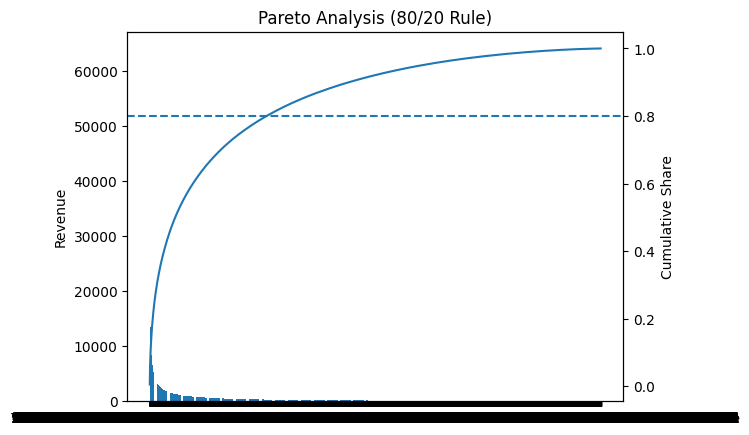

In [13]:
fig, ax1 = plt.subplots()

ax1.bar(pareto_df['product_id'], pareto_df['revenue'])
ax1.set_ylabel('Revenue')

ax2 = ax1.twinx()
ax2.plot(pareto_df['product_id'], pareto_df['cumulative_share'])
ax2.axhline(0.8, linestyle='--')
ax2.set_ylabel('Cumulative Share')

plt.xticks(rotation=90)
plt.title('Pareto Analysis (80/20 Rule)')
plt.show()

In [14]:
top_products = pareto_df[pareto_df['cumulative_share'] <= 0.8]

In [15]:
print(f"Top products contribute {top_products['revenue'].sum() / pareto_df['revenue'].sum() * 100:.2f}% of total revenue")

print(f"Number of top products: {len(top_products)} out of {len(pareto_df)}")

top_percent = len(top_products) / len(pareto_df) * 100
print(f"Top {top_percent:.2f}% of products generate 80% revenue")

Top products contribute 80.00% of total revenue
Number of top products: 8535 out of 32951
Top 25.90% of products generate 80% revenue


### Observation

Unlike the classic 80/20 rule, ~25% of products contribute to 80% of revenue.  
This indicates that revenue distribution is relatively spread out rather than highly concentrated.

In [16]:
orders.info()
orders.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  object        
 1   customer_id                    96478 non-null  object        
 2   order_status                   96478 non-null  object        
 3   order_purchase_timestamp       96478 non-null  datetime64[ns]
 4   order_approved_at              96464 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96476 non-null  datetime64[ns]
 6   order_delivered_customer_date  96470 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96478 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [17]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])


In [18]:
orders = orders[orders['order_status'] == 'delivered']


In [19]:
customers.to_csv('../data/cleaned/customers.csv', index=False)
orders.to_csv('../data/cleaned/orders.csv', index=False)
order_items.to_csv('../data/cleaned/order_items.csv', index=False)
products.to_csv('../data/cleaned/products.csv', index=False)
payments.to_csv('../data/cleaned/payments.csv', index=False)
